# JPSS VIIRS True Color

VIIRS is an orbital swath, not a fixed disk: every pixel carries its own
latitude and longitude in a separate geolocation file. Keep the band files and
their geolocation from the same pass in one folder -- `GMTCO` goes with the M
bands, `GITCO` with the I bands.

Unlike ABI, VIIRS has a real green band, so nothing is synthesised.

Download the files first with the
[GOES & JPSS Data Downloader](https://rmsm95.github.io/GOES-NESDIS_downlaoder/),
then point `DATA_DIR` at the folder they landed in. Nothing is downloaded here.

**Steps:** your files -> the whole scan -> your box -> that box.

The plotting is plain matplotlib and cartopy, written out where it happens, so
change the colours, the projection or anything else right there.

## Setup

In [1]:
import glob
import sys
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import yaml

sys.path.insert(0, "..")
import goestools as gt

CONFIG = yaml.safe_load(open("../config.yml"))
STYLE = CONFIG["style"]          # colours, widths, figure size


## 1. Your files

In [2]:
DATA_DIR = Path("..") / CONFIG["data"]["viirs"]

files = sorted(glob.glob(str(DATA_DIR / "*.h5")))
print(f"{DATA_DIR}: {len(files)} file(s)")
for name in files:
    print("   ", Path(name).name[:48])


../data/viirs: 7 file(s)
    GITCO_npp_d20170128_t1230144_e1231386_b27228_c20
    GMTCO_npp_d20170128_t1230144_e1231386_b27228_c20
    SVI01_npp_d20170128_t1230144_e1231386_b27228_c20
    SVI02_npp_d20170128_t1230144_e1231386_b27228_c20
    SVM03_npp_d20170128_t1230144_e1231386_b27228_c20
    SVM04_npp_d20170128_t1230144_e1231386_b27228_c20
    SVM05_npp_d20170128_t1230144_e1231386_b27228_c20


## 2. The whole granule

The extent comes from the granule's own geolocation, so nothing is cut off.

granule: (768, 3200) at 2017-01-28 12:30:14
extent: -10.6 to 24.5 lon, 31.0 to 41.0 lat


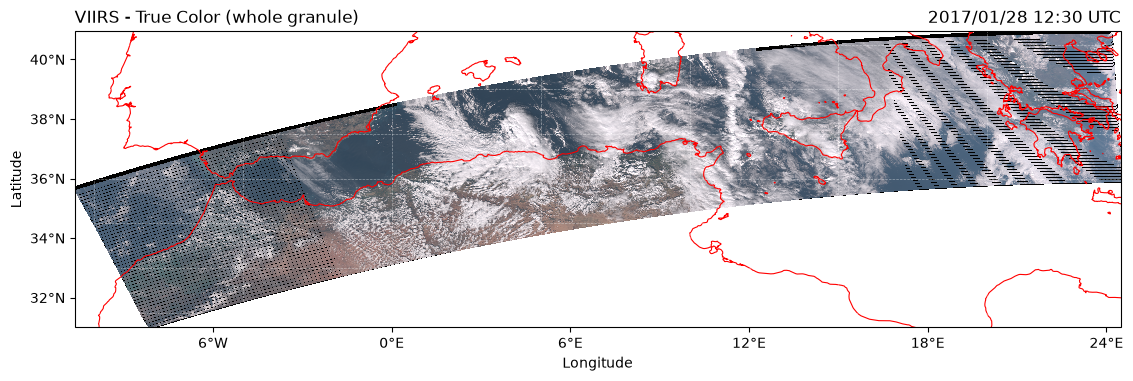

In [3]:
rgb, lon, lat, when = gt.viirs_true_color(DATA_DIR)
print("granule:", rgb.shape[:2], "at", when)

west, east = float(np.nanmin(lon)), float(np.nanmax(lon))
south, north = float(np.nanmin(lat)), float(np.nanmax(lat))
print(f"extent: {west:.1f} to {east:.1f} lon, {south:.1f} to {north:.1f} lat")

fig = plt.figure(figsize=(STYLE["figure_width"], 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.pcolormesh(lon, lat, np.zeros(lon.shape), color=rgb.reshape(-1, 3),
              shading="nearest", transform=ccrs.PlateCarree())

ax.coastlines(resolution=STYLE["coast_resolution"],
              color=STYLE["coast_colour"], linewidth=STYLE["coast_width"])
ax.gridlines(color=STYLE["grid_colour"], alpha=STYLE["grid_alpha"],
             linestyle=STYLE["grid_style"], linewidth=STYLE["grid_width"])
gt.degree_ticks(ax, west, east, south, north)

ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())
ax.set_title("VIIRS - True Color (whole granule)", loc="left")
ax.set_title(f"{when:%Y/%m/%d %H:%M} UTC", loc="right")
plt.show()


## 3. Your box

The box must fall inside the extent printed above: a polar orbiter only sees a
strip, so a pass may simply miss your area.

In [4]:
BOX = (2.0, 8.0, 36.0, 39.0)

print("box:", BOX)


box: (2.0, 8.0, 36.0, 39.0)


## 4. Your box

box: (570, 711) pixels


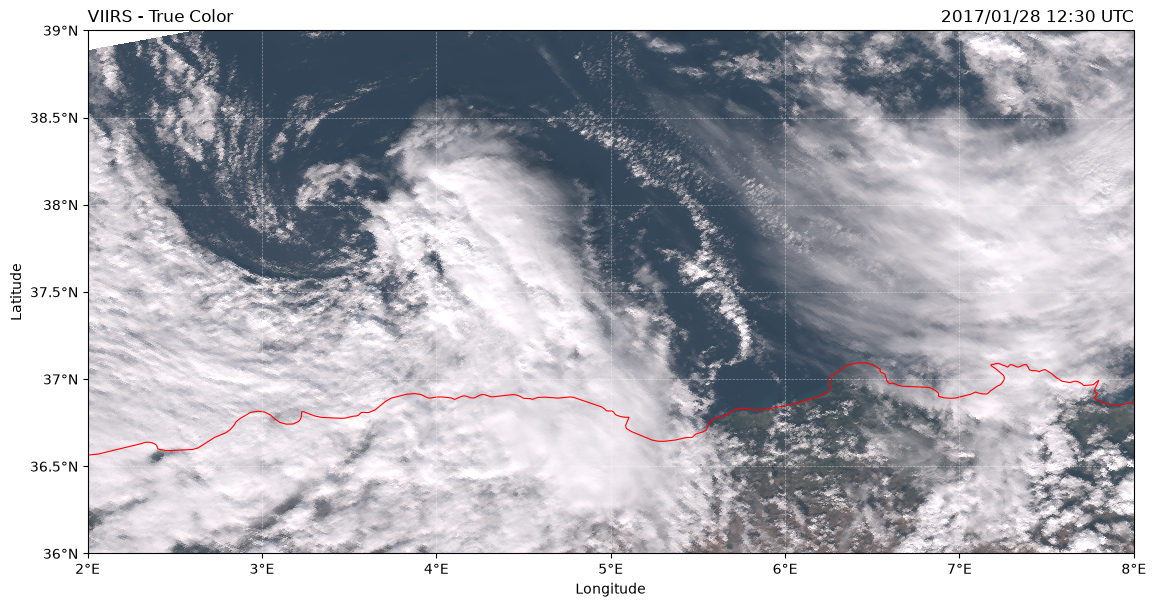

In [5]:
if BOX is None:
    print("No box set.")
else:
    rgb, lon, lat, when = gt.viirs_true_color(DATA_DIR, *BOX)
    print("box:", rgb.shape[:2], "pixels")

    fig = plt.figure(figsize=(STYLE["figure_width"], 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    ax.pcolormesh(lon, lat, np.zeros(lon.shape), color=rgb.reshape(-1, 3),
                  shading="nearest", transform=ccrs.PlateCarree())

    ax.coastlines(resolution=STYLE["coast_resolution"],
                  color=STYLE["coast_colour"], linewidth=STYLE["coast_width"])
    ax.gridlines(color=STYLE["grid_colour"], alpha=STYLE["grid_alpha"],
                 linestyle=STYLE["grid_style"], linewidth=STYLE["grid_width"])
    gt.degree_ticks(ax, *BOX)

    ax.set_extent(BOX, crs=ccrs.PlateCarree())
    ax.set_title("VIIRS - True Color", loc="left")
    ax.set_title(f"{when:%Y/%m/%d %H:%M} UTC", loc="right")
    plt.show()


## Notes

* Prefer the terrain-corrected geolocation: `GMTCO` for M bands, `GITCO` for I.
* The I bands sit on a finer grid than the M bands, so they cannot be mixed in
  one call.
* For continuous coverage of one spot use the GOES notebooks; VIIRS passes over
  an area only a couple of times a day.